# Tracing and designing a phase boundary with path following

The boundary between the one-phase and two-phase regions of a mixture — the **phase
envelope** — is a curve that parameter continuation cannot follow. It doubles back on
itself in pressure at the *cricondenbar* and in temperature at the *cricondentherm*, so
"solve at the next pressure" runs out of solutions while the curve is still going.

This notebook builds the envelope of a natural-gas mixture from the Peng–Robinson
equation of state and traces it with
[`pounce.jax.PathFollower`](https://kitchingroup.cheme.cmu.edu/pounce/path-following.html).
It then turns the trace into an auditable design calculation:

- the equilibrium condition is a **square nonlinear system**, posed to POUNCE the way
  `solve_bvp` poses collocation — as the feasibility NLP `min 0` s.t. `F(X) = 0`
  ([bvp.md](https://kitchingroup.cheme.cmu.edu/pounce/bvp.html));
- pseudo-arclength continuation supplies a bracket at each fold, and an augmented
  simple-fold solve refines the cricondenbar/cricondentherm beyond the trace spacing;
- implicit derivatives quantify how those extrema move with all $N-1$ independent
  composition coordinates and one Peng–Robinson $k_{ij}$;
- an inverse solve changes composition to hit a target cricondentherm, then a completely
  fresh envelope trace checks the design.

Two tempting continuation methods fail here, and one **fails silently**. That is kept in,
because it is the most useful warning in the notebook.


In [1]:
%matplotlib inline
import platform
import subprocess
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pounce
from pounce.jax import PathFollower   # importing pounce.jax enables x64
from pounce.examples.phase_envelope import (
    DEITERS_BELL_METHANE_PROPANE,
    NATURAL_GAS,
    compressibility as pr_compressibility,
    design_composition_for_extremum,
    design_parameters,
    diagnose_phase_point,
    envelope_residual as pr_envelope_residual,
    log_fugacity_coefficients,
    make_envelope_problem,
    mixture_from_design,
    reparameterize_trace,
    refine_fold,
    trace_envelope,
    vapor_pressure,
    wilson_log_k,
    wilson_start as pr_wilson_start,
)

SOURCE_COMMIT = subprocess.check_output(
    ["git", "rev-parse", "HEAD"], text=True
).strip()
print(f"pounce {pounce.__version__}")
print(f"source commit {SOURCE_COMMIT}")
print(f"runtime Python {platform.python_version()}, JAX {jax.__version__}, "
      f"{platform.platform()} [{platform.machine()}], backend={jax.default_backend()}")


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


pounce 0.10.0
source commit 70b3d64fee2be2445ab89a33f07e5fa9f540624a
runtime Python 3.13.5, JAX 0.10.0, Linux-6.6.114.1-microsoft-standard-WSL2-x86_64-with-glibc2.39 [x86_64], backend=cpu


## 1. The mixture and the equilibrium condition

A light natural gas: 80% methane with a heavy tail. The tail is what gives the envelope
its pronounced retrograde region, and therefore its turning points.

At equilibrium the two phases have equal fugacities. Writing $K_i = y_i/x_i$ for the
equilibrium ratios and fixing the vapor fraction $\beta$, the incipient-phase condition
of Michelsen (*Fluid Phase Equilibria* **4**, 1–10, 1980) is

$$
x_i = \frac{z_i}{1-\beta+\beta K_i}, \qquad y_i = K_i x_i,
$$
$$
g_i = \ln K_i + \ln\varphi_i^{\,\mathrm{v}}(\mathbf{y},T,P)
              - \ln\varphi_i^{\,\mathrm{l}}(\mathbf{x},T,P) = 0,
\qquad i = 1\ldots N,
$$
$$
g_{N+1} = \sum_i (y_i - x_i) = 0 .
$$

That is $N+1$ equations. With unknowns $X = [\ln K_1,\ldots,\ln K_N,\ \ln T]$ and the
pressure carried as the continuation parameter $\theta = \ln P$, the system is **square**
— and the solutions as $\theta$ varies sweep out the phase envelope. Everything is in
logs, which keeps $K$, $T$ and $P$ positive without bounds and conditions the Jacobian.

$\beta = 1$ makes the feed the vapor, so the curve starts as the **dew** locus. Keep an
eye on that word: it does not survive the whole trace.

In [2]:
MIXTURE = NATURAL_GAS
R = 8.314462618  # J/mol/K

NAMES = list(MIXTURE.names)
TC = jnp.asarray(MIXTURE.critical_temperature)  # K
PC = jnp.asarray(MIXTURE.critical_pressure)     # Pa
OM = jnp.asarray(MIXTURE.acentric_factor)       # dimensionless
Z_FEED = jnp.asarray(MIXTURE.composition)       # mole fractions
N = MIXTURE.n_components

print(f"{'component':<10} {'z':>6} {'Tc (K)':>8} {'Pc (bar)':>9} {'omega':>7}")
print("-" * 44)
for i, nm in enumerate(NAMES):
    print(f"{nm:<10} {Z_FEED[i]:6.2f} {TC[i]:8.1f} {PC[i]/1e5:9.2f} {OM[i]:7.3f}")
print("\nBinary interaction parameters k_ij = 0 (all light alkanes).")
print(f"constants: {MIXTURE.source}")


component       z   Tc (K)  Pc (bar)   omega
--------------------------------------------
methane      0.80    190.6     45.99   0.012
ethane       0.10    305.3     48.72   0.100
propane      0.06    369.8     42.48   0.152
n-butane     0.04    425.1     37.96   0.200

Binary interaction parameters k_ij = 0 (all light alkanes).
constants: Notebook 34 natural-gas demonstration; all k_ij = 0.


## 2. Peng–Robinson, differentiably

$$
Z^3 - (1-B)Z^2 + (A - 2B - 3B^2)Z - (AB - B^2 - B^3) = 0
$$

The implementation used below lives in the reusable, tested
`pounce.examples.phase_envelope` module; the wrappers in the next cell keep the notation
compact. Two choices in that implementation decide whether any of this works.

**The cubic is solved in closed form.** An iterative root-find or `np.roots` would break
the autodiff chain; the trigonometric Cardano form keeps the whole residual one
differentiable expression.

**Both branches of the root formula are sanitized before the `sqrt`/`arccos`.** Under
`jax.jacobian` the one-real-root and three-real-root branches are *both* evaluated, and a
`NaN` produced in the dead branch propagates into the gradient of the live one even
though `jnp.where` discards its value. Clamping each inactive expression keeps the
Jacobian finite. The next section checks that it does.

The vapor phase takes the largest real root and the liquid the smallest. This is a local
root-selection convention for tracing a known isopleth. It is not a global
tangent-plane-distance (TPD) phase-stability test; that limitation matters for using the
calculation beyond this controlled example.


In [3]:
def compressibility(w, T, P, largest: bool):
    """PR compressibility factor for composition w at (T [K], P [Pa])."""
    return pr_compressibility(w, T, P, MIXTURE, largest=largest)


def ln_phi(w, T, P, largest: bool):
    """PR log fugacity coefficients for composition w at (T [K], P [Pa])."""
    return log_fugacity_coefficients(w, T, P, MIXTURE, largest=largest)


### Does the EOS actually work?

Three checks before anything is built on top of it: the ideal-gas limit, a pure-component
vapor pressure against literature values, and — the one that matters for what follows —
that gradients stay finite in the region where the cubic has one real root *and* in the
region where it has three.

In [4]:
print("ideal-gas limit, Z -> 1 as P -> 0 (feed composition, 300 K):")
for P in [1e3, 1e4, 1e5]:
    print(f"  P = {P:8.1e} Pa   Z_vap = {float(compressibility(Z_FEED, 300.0, P, True)):.6f}")

print("\ngradients through both cubic branches (no NaNs):")
for P, T, tag in [(1e5, 300.0, "one real root"), (1e6, 200.0, "three real roots")]:
    dv = float(jax.grad(lambda t: compressibility(Z_FEED, t, P, True))(T))
    dl = float(jax.grad(lambda t: compressibility(Z_FEED, t, P, False))(T))
    print(f"  {tag:18s} dZ_vap/dT = {dv: .4e}   dZ_liq/dT = {dl: .4e}")

print("\npure n-butane vapor pressure (equal fugacity), vs literature:")
for T, lit in [(273.15, 1.03), (300.0, 2.58), (350.0, 9.42)]:
    psat_bar = vapor_pressure(MIXTURE, 3, T) / 1e5
    print(f"  T = {T:7.2f} K   Psat = {psat_bar:6.3f} bar   (lit ~{lit} bar)")


ideal-gas limit, Z -> 1 as P -> 0 (feed composition, 300 K):


  P =  1.0e+03 Pa   Z_vap = 0.999963
  P =  1.0e+04 Pa   Z_vap = 0.999630
  P =  1.0e+05 Pa   Z_vap = 0.996300

gradients through both cubic branches (no NaNs):


  one real root      dZ_vap/dT =  3.7931e-05   dZ_liq/dT =  3.7931e-05
  three real roots   dZ_vap/dT =  1.8885e-03   dZ_liq/dT =  3.4964e-04

pure n-butane vapor pressure (equal fugacity), vs literature:


  T =  273.15 K   Psat = 35.000 bar   (lit ~1.03 bar)
  T =  300.00 K   Psat = 35.000 bar   (lit ~2.58 bar)
  T =  350.00 K   Psat = 35.000 bar   (lit ~9.42 bar)


## 3. The square system, posed to POUNCE

POUNCE has no `root()` entry point, and it does not need one. A square system is a
**feasibility NLP**: minimise nothing, subject to $F(X)=0$. This is exactly how
`pounce.solve_bvp` poses its collocation residual internally. For a square nonsingular
$J = \partial F/\partial X$ the KKT stationarity $J^{\mathsf T}\lambda = 0$ forces
$\lambda^*=0$, so the interior-point step collapses to $\Delta X = -J^{-1}F$ — the Newton
step, with the barrier machinery contributing nothing.

The parameter is declared with shape `(1,)`: `PathFollower.trace_arclength` requires a
**scalar** continuation parameter.

In [5]:
def envelope_residual(X, lnP, beta):
    """Michelsen residual; X=[lnK_1..lnK_N, lnT], theta=ln(P/Pa)."""
    return pr_envelope_residual(X, lnP, beta, MIXTURE)


def make_problem(beta):
    """min 0 s.t. F(X; lnP)=0 -- a square feasibility NLP."""
    return make_envelope_problem(MIXTURE, beta, mode="pressure")


BETA = 1.0                 # feed is the vapor: the curve starts on the dew locus
jp = make_problem(BETA)
print(f"n = {N+1} unknowns, m = {N+1} equations -- square")


n = 5 unknowns, m = 5 equations -- square


## 4. The easy starting point

Continuation needs somewhere to start, and at low pressure the mixture is nearly ideal,
so the Wilson correlation

$$\ln K_i = \ln(P_{c,i}/P) + 5.373\,(1+\omega_i)(1 - T_{c,i}/T)$$

is a good enough guess to converge from. At $P = 1$ bar the dew temperature follows from
a scalar bisection on $\sum_i z_i/K_i(T) = 1$ — one line, no derivatives — and the full
system then converges from there.

In [6]:
def wilson_lnK(T, P):
    return wilson_log_k(T, P, MIXTURE)


def wilson_start(P0, beta):
    """Wilson K-values plus a scalar incipient-temperature solve."""
    return pr_wilson_start(P0, beta, MIXTURE)


P0 = 1e5                                   # 1 bar
lnP0 = float(np.log(P0))
X_guess, T_wilson = wilson_start(P0, BETA)
X_start = jp.solve(jnp.array([lnP0]), X_guess)

res0 = float(jnp.max(jnp.abs(envelope_residual(X_start, lnP0, BETA))))
print(f"Wilson guess  : T = {T_wilson:.2f} K")
print(f"converged     : T = {float(jnp.exp(X_start[N])):.3f} K at P = {P0/1e5:.2f} bar")
print(f"max|F|        : {res0:.2e}")
print(f"K-values      : {np.array2string(np.exp(np.asarray(X_start[:N])), precision=4)}")


Wilson guess  : T = 209.58 K
converged     : T = 211.684 K at P = 1.00 bar
max|F|        : 1.96e-13
K-values      : [6.6123e+01 3.4459e+00 4.0889e-01 4.9252e-02]


## 5. Attempt 1 — walk up in pressure

The obvious thing: raise the pressure a step at a time, warm-starting each solve from the
last converged point. This is what a parameter sweep looks like, and on the lower part of
the curve it works fine.

In [7]:
pressure_schedule = np.concatenate([np.linspace(1, 90, 30), np.linspace(92, 105, 14)])
Xk = X_start
ladder = [(1.0, float(jnp.exp(X_start[N])))]
last_good = ladder[0]
ladder_attempts = 0
ladder_started = time.perf_counter()
for Pq in pressure_schedule[1:]:
    ladder_attempts += 1
    lnPq = float(np.log(Pq * 1e5))
    Xn = jp.solve(jnp.array([lnPq]), Xk)
    r = float(jnp.max(jnp.abs(envelope_residual(Xn, lnPq, BETA))))
    if r > 1e-8 or not np.all(np.isfinite(np.asarray(Xn))):
        print(f"FAILED at P = {Pq:.2f} bar   (residual {r:.2e})")
        print(f"last good point: P = {last_good[0]:.2f} bar, T = {last_good[1]:.2f} K")
        break
    Xk = Xn
    last_good = (Pq, float(jnp.exp(Xn[N])))
    ladder.append(last_good)
else:
    print("the ladder never failed")

ladder_seconds = time.perf_counter() - ladder_started
ladder_successful_solves = len(ladder) - 1
ladder = np.array(ladder)
print(f"\n{len(ladder)} points climbed, from {ladder[0,0]:.2f} to {ladder[-1,0]:.2f} bar")

FAILED at P = 98.00 bar   (residual 2.17e-04)
last good point: P = 97.00 bar, T = 266.08 K

36 points climbed, from 1.00 to 97.00 bar


It dies. Nothing is wrong with the solver or the starting point: **there is no solution**
at the next pressure. The curve has a maximum in $P$, and the ladder walked into it.

That maximum is a real, named quantity — the *cricondenbar*, the highest pressure at
which two phases can coexist for this mixture. Keep the number in mind; it will come back
as an output rather than an obstacle.

## 6. Attempt 2 — `PathFollower.follow`

`follow` traces $X^*(\theta(s))$ along a **prescribed** path in the parameter, predicting
along the held-factor sensitivity and correcting only when the KKT residual drifts. Since
the ladder above failed by re-solving badly, a predictor-corrector ought to do better.

It reports success.

In [8]:
lnP_end = float(np.log(105e5))
follow_started = time.perf_counter()
pf = PathFollower(jp, monitor_tol=1e-6, ds0=0.05, ds_max=0.2)
tr_follow = pf.follow(lambda u: jnp.array([lnP0 + u * (lnP_end - lnP0)]),
                      (0.0, 1.0), X_start)
follow_seconds = time.perf_counter() - follow_started

P_f = np.exp(tr_follow.theta.reshape(-1)) / 1e5
T_f = np.exp(tr_follow.x[:, N])
print(f"status = {tr_follow.status}   steps = {tr_follow.n_steps}   "
      f"correctors = {tr_follow.n_correctors}   accepts = {tr_follow.n_accepts}")
print(f"reached P = {P_f.max():.2f} bar of the requested 105.00 bar\n")

print(f"{'P (bar)':>9} {'T (K)':>9} {'K_C1':>9} {'K_C2':>9} {'K_C3':>9} {'K_nC4':>9} {'max|F|':>10}")
print("-" * 70)
for k in range(len(P_f)):
    lnPk = float(tr_follow.theta.reshape(-1)[k])
    r = float(jnp.max(jnp.abs(envelope_residual(jnp.asarray(tr_follow.x[k]), lnPk, BETA))))
    K = np.exp(tr_follow.x[k, :N])
    print(f"{P_f[k]:9.3f} {T_f[k]:9.3f} {K[0]:9.4f} {K[1]:9.4f} {K[2]:9.4f} {K[3]:9.4f} {r:10.1e}")

status = ok   steps = 9   correctors = 8   accepts = 0
reached P = 105.00 bar of the requested 105.00 bar

  P (bar)     T (K)      K_C1      K_C2      K_C3     K_nC4     max|F|
----------------------------------------------------------------------
    1.000   211.684   66.1229    3.4459    0.4089    0.0493    2.0e-13
    1.262   215.296   55.6727    3.1362    0.3929    0.0499    4.8e-13
    1.789   220.963   42.9527    2.7235    0.3705    0.0511    5.5e-13
    3.020   230.044   29.0001    2.2049    0.3405    0.0533    3.7e-11
    6.624   244.968   15.9043    1.6087    0.3036    0.0580    6.7e-15
   16.801   264.098    7.5817    1.1143    0.2744    0.0683    8.9e-14
   42.617   281.105    3.3914    0.7934    0.2741    0.0954    1.8e-15
   66.894   283.721    2.1666    0.7017    0.3082    0.1362    2.2e-15
  105.000   255.266    1.0000    1.0000    1.0000    1.0000    8.4e-13


Look at the last row. Every $K_i = 1$, and the residual is $10^{-15}$.

$K_i = 1$ means $\mathbf{x} = \mathbf{y} = \mathbf{z}$: the two phases have identical
compositions, which is to say *there is no phase split*. This is the **trivial solution**,
and it satisfies the equilibrium equations exactly at every temperature and pressure —
put $\ln K_i = 0$ into $g_i$ and both fugacity terms cancel; put $x = y$ into $g_{N+1}$
and the sum is zero. It is a solution of the algebra that is not a phase boundary.

So `follow` did not fail. It converged, to machine precision, onto a solution branch that
carries no physics — and reported `status="ok"` while doing it. The KKT monitor cannot
catch this, because there is genuinely nothing wrong with the point it landed on.

**This is the failure mode to worry about.** The ladder in section 5 failed loudly; this
one failed silently, and a plot of $T$ against $P$ would have looked plausible. Any
continuation on a system with a trivial branch needs the trivial branch watched
explicitly — here, `max|ln K|` collapsing to zero away from the critical point.

## 7. Attempt 3 — pseudo-arclength

Both failures trace to the same cause: $\theta$ was treated as the independent variable.
At the cricondenbar $\partial X^*/\partial\theta$ is singular and the curve doubles back,
so no method that marches in $\theta$ has anywhere to go.

`trace_arclength` parametrises the solution curve by its own **arclength** instead,
solving $R(X,\lambda,\theta) = 0$ in $(X,\lambda,\theta)$ space with an SVD tangent
predictor and a Newton corrector on the augmented system. Arclength never reverses, so
the fold is just another point on the walk — and because the trace steps *along the
tangent* rather than re-solving from scratch, it cannot fall onto the trivial branch.

In [9]:
arclength_started = time.perf_counter()
tr = PathFollower(jp).trace_arclength(X_start, lnP0, ds=0.05, n_steps=400, direction=1.0)
arclength_seconds = time.perf_counter() - arclength_started

P = np.exp(tr.theta) / 1e5
T = np.exp(tr.x[:, N])
lnK_max = np.max(np.abs(tr.x[:, :N]), axis=1)

print(f"status = {tr.status}   steps = {tr.n_steps}   arclength = {tr.s[-1]:.2f}")
print(f"P range: {P.min():.3f} .. {P.max():.2f} bar")
print(f"T range: {T.min():.2f} .. {T.max():.2f} K")
print()
print(f"turning_points (theta = lnP) -> "
      f"{[f'{np.exp(t)/1e5:.2f} bar' for t in tr.turning_points]}")
print(f"  ... the CRICONDENBAR, detected where the theta-component of the tangent")
print(f"      changed sign. The ladder in section 5 died at 98 bar.")
print("\nmethod comparison on the stamped runtime above")
print(f"{'method':<20} {'outcome':<23} {'solves/correctors':>18} {'points':>8} {'wall (s)':>10}")
print("-" * 83)
print(f"{'pressure ladder':<20} {'failed at fold':<23} {ladder_successful_solves:18d} {len(ladder):8d} {ladder_seconds:10.3f}")
print(f"{'parameter follow':<20} {'trivial branch':<23} {tr_follow.n_correctors:18d} {len(tr_follow.x):8d} {follow_seconds:10.3f}")
print(f"{'pseudo-arclength':<20} {tr.status:<23} {tr.n_correctors:18d} {len(tr.x):8d} {arclength_seconds:10.3f}")
print(f"ladder attempts after the shared anchor: {ladder_attempts} "
      f"({ladder_attempts - ladder_successful_solves} rejected); "
      "PathFollower restart and factorization counts are not exposed.")
print("Wall times use perf_counter and exclude the shared low-pressure anchor.")

status = corrector_failed   steps = 322   arclength = 16.10
P range: 1.000 .. 97.59 bar
T range: 183.03 .. 283.93 K

turning_points (theta = lnP) -> ['97.59 bar']
  ... the CRICONDENBAR, detected where the theta-component of the tangent
      changed sign. The ladder in section 5 died at 98 bar.

method comparison on the stamped runtime above
method               outcome                  solves/correctors   points   wall (s)
-----------------------------------------------------------------------------------
pressure ladder      failed at fold                          35       36      1.640
parameter follow     trivial branch                           8        9     16.066
pseudo-arclength     corrector_failed                       322      323      5.702
ladder attempts after the shared anchor: 36 (1 rejected); PathFollower restart and factorization counts are not exposed.
Wall times use perf_counter and exclude the shared low-pressure anchor.


The full envelope, coloured by arclength so the trace reads as one continuous walk.

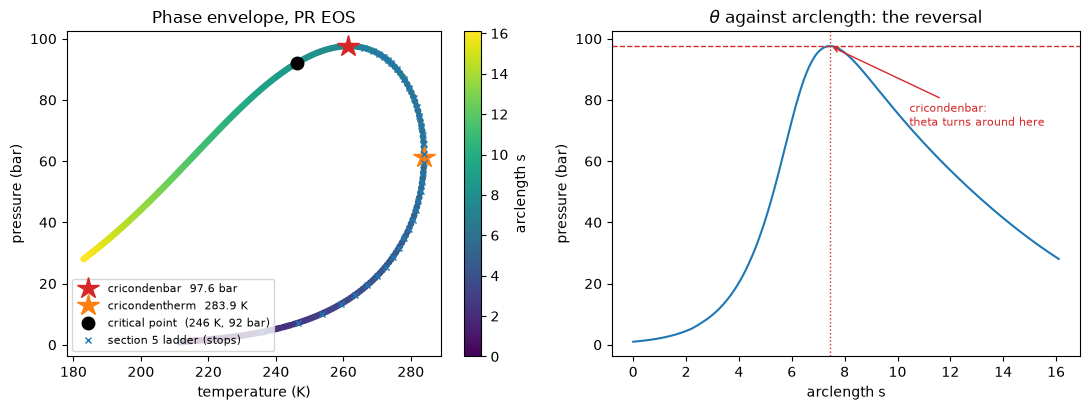

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

sc = ax[0].scatter(T, P, c=tr.s, cmap="viridis", s=14, zorder=3)
ax[0].plot(T, P, "-", color="0.75", lw=0.8, zorder=2)
icb = int(np.argmax(P))
ict = int(np.argmax(T))
icrit = int(np.argmin(lnK_max))
ax[0].plot(T[icb], P[icb], "*", ms=16, color="C3", zorder=4,
           label=f"cricondenbar  {P[icb]:.1f} bar")
ax[0].plot(T[ict], P[ict], "*", ms=16, color="C1", zorder=4,
           label=f"cricondentherm  {T[ict]:.1f} K")
ax[0].plot(T[icrit], P[icrit], "o", ms=9, color="k", zorder=4,
           label=f"critical point  ({T[icrit]:.0f} K, {P[icrit]:.0f} bar)")
ax[0].plot(ladder[:, 1], ladder[:, 0], "x", color="C0", ms=4, zorder=5,
           label="section 5 ladder (stops)")
ax[0].set_xlabel("temperature (K)")
ax[0].set_ylabel("pressure (bar)")
ax[0].set_title("Phase envelope, PR EOS")
ax[0].legend(fontsize=8, loc="lower left")
fig.colorbar(sc, ax=ax[0], label="arclength s")

ax[1].plot(tr.s, P, "-", color="C0")
for t in tr.turning_points:
    ax[1].axhline(np.exp(t) / 1e5, color="C3", ls="--", lw=1)
    ax[1].axvline(tr.s[icb], color="C3", ls=":", lw=1)
ax[1].set_xlabel("arclength s")
ax[1].set_ylabel("pressure (bar)")
ax[1].set_title(r"$\theta$ against arclength: the reversal")
ax[1].annotate("cricondenbar:\ntheta turns around here",
               xy=(tr.s[icb], P[icb]), xytext=(tr.s[icb] + 3.0, P[icb] - 26),
               arrowprops=dict(arrowstyle="->", color="C3"), fontsize=8, color="C3")
fig.tight_layout()
plt.show()

The right panel is the whole argument in one line. Pressure rises, reverses, and falls
again. At that reversal a method marching in $P$ has nowhere to go — and the two-phase
region *inside* the loop is precisely the answer being computed: outside it the mixture
is a single phase.

## 8. The other turning point

The cricondenbar was detected because pressure was the continuation parameter. Swap the
roles — carry $\ln P$ as a state and continue in $\theta = \ln T$ — and the same
machinery detects the *cricondentherm* instead, the highest temperature at which two
phases coexist.

The two runs are independent parameterizations of the same curve, so each one's detected
turning point must equal the other's plain maximum. That is a real check, not a
restatement.

In [11]:
jpT = make_envelope_problem(MIXTURE, BETA, mode="temperature")
lnT0 = float(X_start[N])
XT_start = jpT.solve(jnp.array([lnT0]),
                     jnp.concatenate([X_start[:N], jnp.array([lnP0])]))
trT = PathFollower(jpT).trace_arclength(XT_start, lnT0, ds=0.05, n_steps=400,
                                        direction=1.0)
P_T = np.exp(trT.x[:, N]) / 1e5

print(f"theta = lnT run: status = {trT.status}, steps = {trT.n_steps}")
print()
print(f"{'quantity':<18} {'detected as a turning point':>30} {'plain max of the other run':>29}")
print("-" * 79)
print(f"{'cricondentherm':<18} "
      f"{f'{np.exp(trT.turning_points[0]):.2f} K':>30} {f'{T.max():.2f} K':>29}")
print(f"{'cricondenbar':<18} "
      f"{f'{np.exp(tr.turning_points[0])/1e5:.2f} bar':>30} {f'{P_T.max():.2f} bar':>29}")
print()
print(f"agreement: {abs(np.exp(trT.turning_points[0]) - T.max()):.3f} K, "
      f"{abs(np.exp(tr.turning_points[0])/1e5 - P_T.max()):.3f} bar "
      f"(turning points are detected to the ds sampling resolution)")


theta = lnT run: status = corrector_failed, steps = 323

quantity              detected as a turning point    plain max of the other run
-------------------------------------------------------------------------------
cricondentherm                           283.91 K                      283.93 K
cricondenbar                            97.59 bar                     97.58 bar

agreement: 0.018 K, 0.002 bar (turning points are detected to the ds sampling resolution)


## 9. Through the critical point — the trace changes what it is computing

Follow `max|ln K|` along the walk. It starts large, collapses almost to zero, and grows
again. Where it touches zero all $K_i = 1$: the two phases have become identical. That is
the **mixture critical point**.

What happens on the far side is the interesting part. The $K$-values *invert* — methane's
$K$ crosses from above 1 to below 1 — which means the phase carrying the feed composition
switches from being the vapor to being the liquid. The trace started on the dew locus and
came out on the **bubble** locus, without being told to. One continuation, from one
low-pressure starting point, produced the entire envelope.

(This is also why section 6's collapse onto $K \equiv 1$ was so easy to miss: near the
critical point the trivial branch and the physical branch genuinely meet.)

closest sampled point: max|lnK| = 0.00465 at T = 246.42 K, P = 92.21 bar
parabola-refined     : T_c = 246.35 K, P_c = 92.16 bar
K-values there       : [1.00066 0.99848 0.99692 0.99536]

                  K_C1      K_C2      K_C3     K_nC4   phase carrying the feed
----------------------------------------------------------------------------
before           1.244     0.753     0.524     0.365   vapor  -> DEW branch
after            0.906     1.406     1.936     2.661   liquid -> BUBBLE branch


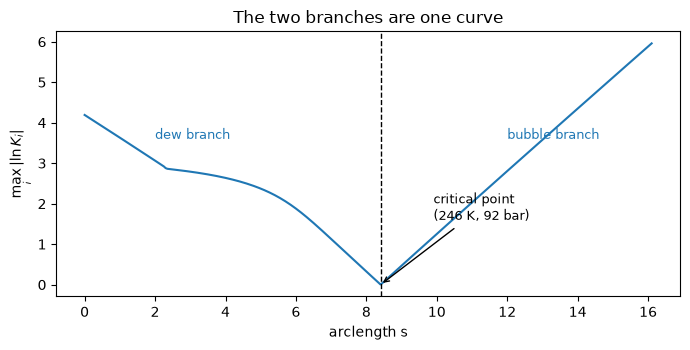

In [12]:
icrit = int(np.argmin(lnK_max))
sl = slice(icrit - 3, icrit + 4)
c = np.polyfit(tr.s[sl], lnK_max[sl], 2)
s_crit = -c[1] / (2 * c[0])
T_crit = np.interp(s_crit, tr.s, T)
P_crit = np.interp(s_crit, tr.s, P)

print(f"closest sampled point: max|lnK| = {lnK_max[icrit]:.5f} "
      f"at T = {T[icrit]:.2f} K, P = {P[icrit]:.2f} bar")
print(f"parabola-refined     : T_c = {T_crit:.2f} K, P_c = {P_crit:.2f} bar")
print(f"K-values there       : {np.array2string(np.exp(tr.x[icrit, :N]), precision=5)}")
print()
print(f"{'':<12} {'K_C1':>9} {'K_C2':>9} {'K_C3':>9} {'K_nC4':>9}   phase carrying the feed")
print("-" * 76)
kb = np.exp(tr.x[icrit - 25, :N])
ka = np.exp(tr.x[icrit + 25, :N])
print(f"{'before':<12} {kb[0]:9.3f} {kb[1]:9.3f} {kb[2]:9.3f} {kb[3]:9.3f}   "
      f"vapor  -> DEW branch")
print(f"{'after':<12} {ka[0]:9.3f} {ka[1]:9.3f} {ka[2]:9.3f} {ka[3]:9.3f}   "
      f"liquid -> BUBBLE branch")

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(tr.s, lnK_max, "-", color="C0")
ax.axvline(s_crit, color="k", ls="--", lw=1)
ax.annotate(f"critical point\n({T_crit:.0f} K, {P_crit:.0f} bar)",
            xy=(s_crit, 0.0), xytext=(s_crit + 1.5, 1.6),
            arrowprops=dict(arrowstyle="->"), fontsize=9)
ax.text(2.0, 3.6, "dew branch", color="C0", fontsize=9)
ax.text(12.0, 3.6, "bubble branch", color="C0", fontsize=9)
ax.set_xlabel("arclength s")
ax.set_ylabel(r"$\max_i |\ln K_i|$")
ax.set_title("The two branches are one curve")
fig.tight_layout()
plt.show()

## 10. Sensitivity *is* the slope of the phase boundary

The tangent that steps the continuation is the same object as
$\partial \ln T/\partial \ln P$ along the envelope — the Clapeyron-like slope of the
phase boundary. `sensitivity_at` returns it from the KKT factor at any converged point.

At the cricondenbar the boundary is horizontal in $(T,P)$, so $dP/dT \to 0$ and this
sensitivity **diverges**. The number the continuation needs and the number that blows up
are the same number; that is the whole reason parameter continuation cannot get past the
fold, stated quantitatively.

sensitivity_at vs finite difference along the path: max rel err = 9.80e-03
  (finite differencing a curved path at ds=0.05 is the less accurate of the two)

|dlnT/dlnP| on the low-pressure dew branch : 0.073
|dlnT/dlnP| nearest the cricondenbar       : 8.7   (120x larger, and unbounded at the fold)


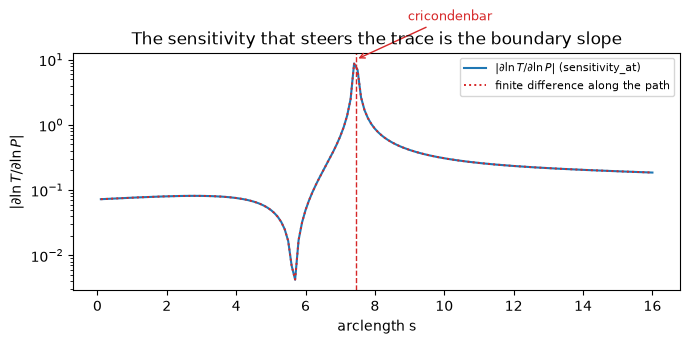

In [13]:
zn = jnp.zeros(N + 1)
ks = np.arange(2, len(tr.s) - 2, 2)
dlnT_dlnP = np.array([
    float(np.asarray(jp.sensitivity_at(jnp.asarray(tr.x[k]),
                                       jnp.array([float(tr.theta[k])]),
                                       (jnp.zeros(N + 1), zn, zn))).reshape(-1)[N])
    for k in ks])
fd = np.array([(tr.x[k+1, N] - tr.x[k-1, N]) / (tr.theta[k+1] - tr.theta[k-1]) for k in ks])

good = np.abs(fd) < 50
rel = np.max(np.abs(dlnT_dlnP[good] - fd[good]) / (1.0 + np.abs(fd[good])))
print(f"sensitivity_at vs finite difference along the path: max rel err = {rel:.2e}")
print(f"  (finite differencing a curved path at ds=0.05 is the less accurate of the two)")
print()
k_cb = int(np.argmin(np.abs(ks - icb)))
print(f"|dlnT/dlnP| on the low-pressure dew branch : {abs(dlnT_dlnP[1]):.3f}")
print(f"|dlnT/dlnP| nearest the cricondenbar       : {abs(dlnT_dlnP[k_cb]):.1f}"
      f"   ({abs(dlnT_dlnP[k_cb])/abs(dlnT_dlnP[1]):.0f}x larger, and unbounded at the fold)")

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.semilogy(tr.s[ks], np.abs(dlnT_dlnP), "-", color="C0", label=r"|$\partial\ln T/\partial\ln P$| (sensitivity_at)")
ax.semilogy(tr.s[ks], np.abs(fd), ":", color="C3", lw=1.4, label="finite difference along the path")
ax.axvline(tr.s[icb], color="C3", ls="--", lw=1)
ax.annotate("cricondenbar", xy=(tr.s[icb], 10), xytext=(tr.s[icb] + 1.5, 40),
            arrowprops=dict(arrowstyle="->", color="C3"), fontsize=9, color="C3")
ax.set_xlabel("arclength s")
ax.set_ylabel(r"$|\partial \ln T / \partial \ln P|$")
ax.set_title("The sensitivity that steers the trace is the boundary slope")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 11. Retrograde condensation

The physical payoff of the fold. For a temperature between the critical temperature and
the cricondentherm, a *vertical* line crosses the dew branch **twice** — so lowering the
pressure at fixed temperature makes liquid appear and then disappear again. That is
retrograde condensation, and it is why gas-condensate reservoirs drop liquid as they are
produced.

A method that could only march up in pressure would have found the first of each pair and
stopped.

In [14]:
dew = slice(0, icrit)
print(f"{'T (K)':>8}   dew pressures (bar)")
print("-" * 34)
for Tq in [255.0, 265.0, 275.0]:
    hits = [0.5 * (P[i] + P[i + 1]) for i in range(icrit - 1)
            if (T[i] - Tq) * (T[i + 1] - Tq) < 0]
    print(f"{Tq:8.1f}   {'  and  '.join(f'{p:.1f}' for p in sorted(hits))}")
print(f"\ncritical T = {T_crit:.1f} K,  cricondentherm = {T.max():.1f} K")
print("between those two temperatures every isotherm meets the dew branch twice.")

   T (K)   dew pressures (bar)
----------------------------------
   255.0   10.7  and  96.5
   265.0   17.3  and  97.3
   275.0   29.5  and  91.2

critical T = 246.4 K,  cricondentherm = 283.9 K
between those two temperatures every isotherm meets the dew branch twice.


## 12. Refine the sampled extrema

`PathTrace.turning_points` detects and brackets a fold, but its reported coordinate is a
trace sample. For a design calculation that is not enough. A simple fold satisfies

$$F(X,\theta,q)=0,\qquad F_Xv=0,\qquad v^Tv=1,$$

where $v$ spans the null space of the state Jacobian. The augmented system is square and
`refine_fold` solves it with POUNCE, seeded by the arclength bracket. The same implicit
solve returns derivatives with respect to $N-1$ log-ratio coordinates
$\eta_i=\log(z_i/z_N)$ and the selected binary interaction parameter $k_{ij}$.


In [15]:
KIJ_PAIR = (0, 1)
pressure_fold = refine_fold(
    tr, MIXTURE, beta=BETA, mode="pressure", kij_pair=KIJ_PAIR
)
temperature_fold = refine_fold(
    trT, MIXTURE, beta=BETA, mode="temperature", kij_pair=KIJ_PAIR
)

print("sampled -> augmented-fold refinement")
print(f"  cricondenbar : {P.max():.6f} -> {pressure_fold.pressure_pa/1e5:.6f} bar"
      f"   max|G|={pressure_fold.max_residual:.2e}")
print(f"  cricondentherm: {T.max():.6f} -> {temperature_fold.temperature_k:.6f} K"
      f"   max|G|={temperature_fold.max_residual:.2e}")

labels = [f"eta({name}/{NAMES[-1]})" for name in NAMES[:-1]] + ["k(methane,ethane)"]
print("\nd(extremum)/d(design coordinate)")
print(f"{'coordinate':<24} {'dP@Pmax (bar)':>16} {'dT@Pmax (K)':>16} "
      f"{'dT@Tmax (K)':>16} {'dP@Tmax (bar)':>16}")
print("-" * 94)
for label, dp_p, dt_p, dt_t, dp_t in zip(
    labels,
    pressure_fold.pressure_design_jacobian / 1e5,
    pressure_fold.temperature_design_jacobian,
    temperature_fold.temperature_design_jacobian,
    temperature_fold.pressure_design_jacobian / 1e5,
):
    print(f"{label:<24} {dp_p:16.6f} {dt_p:16.6f} {dt_t:16.6f} {dp_t:16.6f}")

pressure_guard = diagnose_phase_point(
    pressure_fold.state, pressure_fold.log_parameter, MIXTURE,
    beta=BETA, mode="pressure",
)
temperature_guard = diagnose_phase_point(
    temperature_fold.state, temperature_fold.log_parameter, MIXTURE,
    beta=BETA, mode="temperature",
)
print("\nlocal physical guards:")
print(f"  pressure fold: branch distance={pressure_guard.branch_distance:.3f}, "
      f"roots admissible={pressure_guard.roots_are_admissible}")
print(f"  temperature fold: branch distance={temperature_guard.branch_distance:.3f}, "
      f"roots admissible={temperature_guard.roots_are_admissible}")


sampled -> augmented-fold refinement
  cricondenbar : 97.585989 -> 97.586395 bar   max|G|=1.40e-14
  cricondentherm: 283.927476 -> 283.929158 K   max|G|=4.00e-15

d(extremum)/d(design coordinate)
coordinate                  dP@Pmax (bar)      dT@Pmax (K)      dT@Tmax (K)    dP@Tmax (bar)
----------------------------------------------------------------------------------------------
eta(methane/n-butane)          -11.069289       -28.958421       -31.806505       -11.221313
eta(ethane/n-butane)            -6.285223         3.896606         0.192001         0.311296
eta(propane/n-butane)            3.103358         9.106585         9.026152         4.973164
k(methane,ethane)               22.238633       -13.426851        -1.407651         2.408811

local physical guards:
  pressure fold: branch distance=0.771, roots admissible=True
  temperature fold: branch distance=2.079, roots admissible=True


## 13. Independent published benchmark and full-retrace sensitivities

The four-component example is useful but not an independent reference. Deiters and Bell,
*AIChE Journal* **65** (2019), e16730
([doi:10.1002/aic.16730](https://doi.org/10.1002/aic.16730)), report a 282.53 K
maxcondentherm for the Peng–Robinson methane/propane liquid isopleth at
$x_\mathrm{methane}=0.8$, using $k_{12}=0.042823$. Their constants are encoded with
provenance in `DEITERS_BELL_METHANE_PROPANE`.

First, coarse and fine arclength traces must converge to the same augmented cricondenbar
and cricondentherm, including the pressure and temperature at each fold. For the derivative
check we then deliberately pay for four complete, independent envelope retraces: positive
and negative perturbations of the one binary simplex coordinate and of $k_{12}$. Every
retrace refines both folds. Agreement is stronger evidence than differentiating a second
expression at the same fold.


In [16]:
REFERENCE = DEITERS_BELL_METHANE_PROPANE
REFERENCE_PAIR = (0, 1)
reference_trace = trace_envelope(
    REFERENCE, beta=0.0, mode="temperature", ds=0.1, n_steps=145
)
reference_fold = refine_fold(
    reference_trace, REFERENCE, beta=0.0, mode="temperature",
    kij_pair=REFERENCE_PAIR,
)
reference_pressure_fold = refine_fold(
    reparameterize_trace(
        reference_trace, REFERENCE, from_mode="temperature", to_mode="pressure"
    ),
    REFERENCE, beta=0.0, mode="pressure", kij_pair=REFERENCE_PAIR,
)
fine_trace = trace_envelope(
    REFERENCE, beta=0.0, mode="temperature", ds=0.08, n_steps=180
)
fine_temperature_fold = refine_fold(
    fine_trace, REFERENCE, beta=0.0, mode="temperature", kij_pair=REFERENCE_PAIR,
)
fine_pressure_fold = refine_fold(
    reparameterize_trace(
        fine_trace, REFERENCE, from_mode="temperature", to_mode="pressure"
    ),
    REFERENCE, beta=0.0, mode="pressure", kij_pair=REFERENCE_PAIR,
)
reference_guard = diagnose_phase_point(
    reference_fold.state, reference_fold.log_parameter, REFERENCE,
    beta=0.0, mode="temperature",
)

print(f"published maxcondentherm : 282.530000 K")
print(f"POUNCE refined value     : {reference_fold.temperature_k:.6f} K")
print(f"absolute difference      : {abs(reference_fold.temperature_k - 282.53):.6f} K")
print(f"fold max|G|              : {reference_fold.max_residual:.2e}")
print(f"branch distance          : {reference_guard.branch_distance:.3f}")
print(f"roots admissible         : {reference_guard.roots_are_admissible}")

output_labels = ["P at Pmax", "T at Pmax", "T at Tmax", "P at Tmax"]
output_units = ["bar", "K", "K", "bar"]
output_scales = np.array([1e5, 1.0, 1.0, 1e5])
reference_outputs = np.array([
    reference_pressure_fold.pressure_pa,
    reference_pressure_fold.temperature_k,
    reference_fold.temperature_k,
    reference_fold.pressure_pa,
])
fine_outputs = np.array([
    fine_pressure_fold.pressure_pa,
    fine_pressure_fold.temperature_k,
    fine_temperature_fold.temperature_k,
    fine_temperature_fold.pressure_pa,
])
step_size_delta = np.abs(fine_outputs - reference_outputs) / output_scales
print("\ncontinuation step-size convergence after augmented refinement")
print(f"{'output':<14} {'ds=0.10':>15} {'ds=0.08':>15} {'absolute delta':>18}")
print("-" * 66)
for label, unit, coarse, fine, delta, scale in zip(
    output_labels, output_units, reference_outputs, fine_outputs,
    step_size_delta, output_scales,
):
    print(f"{label:<14} {coarse/scale:15.8f} {fine/scale:15.8f} "
          f"{delta:14.2e} {unit}")

q_reference = design_parameters(REFERENCE, REFERENCE_PAIR)
central_retrace = np.empty((4, q_reference.size))
for column, step in enumerate((1e-4, 1e-5)):
    extrema = []
    for sign in (-1.0, 1.0):
        perturbed = q_reference.copy()
        perturbed[column] += sign * step
        perturbed_mixture = mixture_from_design(
            REFERENCE, perturbed, REFERENCE_PAIR
        )
        perturbed_trace = trace_envelope(
            perturbed_mixture, beta=0.0, mode="temperature",
            ds=0.1, n_steps=145,
        )
        perturbed_temperature_fold = refine_fold(
            perturbed_trace, perturbed_mixture, beta=0.0,
            mode="temperature", kij_pair=REFERENCE_PAIR,
        )
        perturbed_pressure_fold = refine_fold(
            reparameterize_trace(
                perturbed_trace, perturbed_mixture,
                from_mode="temperature", to_mode="pressure",
            ),
            perturbed_mixture, beta=0.0, mode="pressure",
            kij_pair=REFERENCE_PAIR,
        )
        extrema.append(np.array([
            perturbed_pressure_fold.pressure_pa,
            perturbed_pressure_fold.temperature_k,
            perturbed_temperature_fold.temperature_k,
            perturbed_temperature_fold.pressure_pa,
        ]))
    central_retrace[:, column] = (extrema[1] - extrema[0]) / (2.0 * step)

implicit = np.vstack([
    reference_pressure_fold.pressure_design_jacobian,
    reference_pressure_fold.temperature_design_jacobian,
    reference_fold.temperature_design_jacobian,
    reference_fold.pressure_design_jacobian,
])
retrace_relative_error = np.abs((central_retrace - implicit) / implicit)
print("\nfull-retrace central differences")
print(f"{'output / coordinate':<38} {'implicit':>16} {'central':>16} {'rel. error':>14}")
print("-" * 88)
coordinates = ["eta(methane/propane)", "k(methane,propane)"]
for row, (output, unit, scale) in enumerate(zip(
    output_labels, output_units, output_scales
)):
    for column, coordinate in enumerate(coordinates):
        label = f"{output} / {coordinate}"
        print(f"{label:<38} {implicit[row,column]/scale:16.8f} "
              f"{central_retrace[row,column]/scale:16.8f} "
              f"{retrace_relative_error[row,column]:14.2e} {unit}")


published maxcondentherm : 282.530000 K
POUNCE refined value     : 282.525286 K
absolute difference      : 0.004714 K
fold max|G|              : 9.81e-14
branch distance          : 1.137
roots admissible         : True

continuation step-size convergence after augmented refinement
output                 ds=0.10         ds=0.08     absolute delta
------------------------------------------------------------------
P at Pmax          98.48770600     98.48770600       1.75e-12 bar
T at Pmax         262.07381048    262.07381048       6.99e-12 K
T at Tmax         282.52528552    282.52528552       5.12e-13 K
P at Tmax          67.43237642     67.43237642       2.42e-13 bar



full-retrace central differences
output / coordinate                            implicit          central     rel. error
----------------------------------------------------------------------------------------
P at Pmax / eta(methane/propane)           -13.29038506     -13.29038502       2.99e-09 bar
P at Pmax / k(methane,propane)              51.46577108      51.46577124       3.06e-09 bar
T at Pmax / eta(methane/propane)           -30.11648659     -30.11648658       3.28e-10 K
T at Pmax / k(methane,propane)             -39.17375906     -39.17375917       2.95e-09 K
T at Tmax / eta(methane/propane)           -35.77532050     -35.77532048       4.26e-10 K
T at Tmax / k(methane,propane)             -12.18426692     -12.18426692       4.25e-10 K
P at Tmax / eta(methane/propane)           -10.97071534     -10.97071532       1.99e-09 bar
P at Tmax / k(methane,propane)               4.22319587       4.22319592       1.35e-08 bar


## 14. Inverse design, then a fresh envelope trace

Now ask for a 280 K maxcondentherm while holding $k_{12}$ fixed. The design variables
are the unconstrained composition log ratios, so every iterate stays strictly inside the
simplex. The objective minimizes the squared log-ratio change from the published feed.

Hitting the target inside the augmented design NLP is only an internal consistency check.
The result below is accepted only after rebuilding the mixture, starting again from its
low-pressure Wilson anchor, tracing a new envelope, and independently refining its fold.
That retrace verifies the designed object rather than the optimizer's own constraint
residual. The requested traversal continues beyond both extrema until a corrector is
rejected; the last accepted point and its physical guards are reported, rather than
silently stopping at an arbitrary step count. A terminal corrector rejection is numerical
coverage evidence, not a proof that every possible branch was found. This remains a local
nonconvex design; the retrace verifies feasibility and the target, not global optimality.


In [17]:
TARGET_TEMPERATURE = 280.0  # K
designed = design_composition_for_extremum(
    reference_fold,
    REFERENCE,
    beta=0.0,
    target=TARGET_TEMPERATURE,
    kij_pair=REFERENCE_PAIR,
)

verification_trace = trace_envelope(
    designed.mixture, beta=0.0, mode="temperature", ds=0.1, n_steps=170
)
verification_fold = refine_fold(
    verification_trace, designed.mixture, beta=0.0,
    mode="temperature", kij_pair=REFERENCE_PAIR,
)
verification_guard = diagnose_phase_point(
    verification_fold.state, verification_fold.log_parameter, designed.mixture,
    beta=0.0, mode="temperature",
)
verification_end_guard = diagnose_phase_point(
    verification_trace.x[-1], verification_trace.theta[-1], designed.mixture,
    beta=0.0, mode="temperature",
)
verification_end_temperature = float(np.exp(verification_trace.theta[-1]))
verification_end_pressure_bar = float(
    np.exp(verification_trace.x[-1, designed.mixture.n_components]) / 1e5
)

print(f"original composition : {REFERENCE.composition}")
print(f"designed composition : {designed.mixture.composition}")
print(f"sum(z) / min(z)      : {designed.mixture.composition.sum():.12f} / "
      f"{designed.mixture.composition.min():.6f}")
print(f"design-NLP target    : {designed.achieved:.9f} K  "
      f"(max|G|={designed.max_residual:.2e})")
print(f"fresh retrace/refine : {verification_fold.temperature_k:.9f} K  "
      f"(max|G|={verification_fold.max_residual:.2e})")
print(f"independent error    : "
      f"{abs(verification_fold.temperature_k - TARGET_TEMPERATURE):.2e} K")
print(f"branch distance      : {verification_guard.branch_distance:.3f}")
print(f"full traversal       : status={verification_trace.status}, "
      f"accepted steps={verification_trace.n_steps}, "
      f"end=({verification_end_pressure_bar:.3f} bar, "
      f"{verification_end_temperature:.3f} K)")
print(f"terminal branch      : distance={verification_end_guard.branch_distance:.3f}, "
      f"roots admissible={verification_end_guard.roots_are_admissible}")


original composition : [0.8 0.2]
designed composition : [0.81107132 0.18892868]
sum(z) / min(z)      : 1.000000000000 / 0.188929
design-NLP target    : 280.000000000 K  (max|G|=3.42e-13)
fresh retrace/refine : 280.000000000 K  (max|G|=1.44e-15)
independent error    : 3.02e-11 K
branch distance      : 1.190
full traversal       : status=corrector_failed, accepted steps=156, end=(11.962 bar, 247.104 K)
terminal branch      : distance=2.316, roots admissible=True


## 15. Verification

Every claim above, as a number. The source commit printed at the top stamps the exact
implementation on which these measurements were taken.


In [18]:
res_all = np.array([float(jnp.max(jnp.abs(envelope_residual(jnp.asarray(x), float(t), BETA))))
                    for x, t in zip(tr.x, tr.theta)])
print(f"1. max|F| over all {len(res_all)} traced points        : {res_all.max():.2e}")
assert res_all.max() < 1e-8

d_tp = abs(np.exp(trT.turning_points[0]) - T.max())
d_pb = abs(np.exp(tr.turning_points[0]) / 1e5 - P_T.max())
print(f"2. cricondentherm, two parameterizations       : {d_tp:.3f} K apart")
print(f"   cricondenbar,   two parameterizations       : {d_pb:.3f} bar apart")
assert d_tp < 0.5 and d_pb < 0.5

print(f"3. augmented natural-gas fold residuals        : "
      f"{pressure_fold.max_residual:.2e}, {temperature_fold.max_residual:.2e}")
assert pressure_fold.max_residual < 1e-9
assert temperature_fold.max_residual < 1e-9
assert pressure_guard.roots_are_admissible
assert temperature_guard.roots_are_admissible

published_error = abs(reference_fold.temperature_k - 282.53)
print(f"4. published 282.53 K maxcondentherm error      : {published_error:.4f} K")
assert published_error < 0.02
assert reference_fold.max_residual < 1e-9
assert reference_guard.roots_are_admissible
assert reference_guard.branch_distance > 0.5
print(f"   coarse/fine augmented-fold max delta       : "
      f"{step_size_delta.max():.2e} in reported units")
assert step_size_delta.max() < 1e-5

print(f"5. four-output sensitivities vs full retraces : "
      f"{retrace_relative_error.max():.2e} max rel")
assert retrace_relative_error.max() < 1e-5

inverse_error = abs(verification_fold.temperature_k - TARGET_TEMPERATURE)
print(f"6. inverse design after fresh envelope retrace : {inverse_error:.2e} K")
assert inverse_error < 1e-6
assert verification_fold.max_residual < 1e-9
assert verification_guard.roots_are_admissible
assert verification_guard.branch_distance > 0.5
assert np.isclose(verification_guard.liquid_sum, 1.0, atol=1e-10)
assert np.isclose(verification_guard.vapor_sum, 1.0, atol=1e-10)
assert verification_trace.status == "corrector_failed"
assert verification_trace.n_steps > 145
assert verification_end_guard.max_residual < 1e-9
assert verification_end_guard.roots_are_admissible
assert verification_end_guard.branch_distance > 0.5
assert verification_end_pressure_bar < verification_fold.pressure_pa / 1e5

print(f"7. critical point, max|K_i - 1|                : "
      f"{np.max(np.abs(np.exp(tr.x[icrit, :N]) - 1.0)):.2e}")
assert np.max(np.abs(np.exp(tr.x[icrit, :N]) - 1.0)) < 0.01

print(f"8. sensitivity_at vs finite difference         : {rel:.2e} rel")
assert rel < 0.1

k_before, k_after = np.exp(tr.x[icrit - 25, 0]), np.exp(tr.x[icrit + 25, 0])
print(f"9. K_methane inverts across the critical point : {k_before:.3f} -> {k_after:.3f}")
assert k_before > 1.0 > k_after

n_two = sum(len([1 for i in range(icrit - 1) if (T[i] - Tq) * (T[i + 1] - Tq) < 0]) == 2
            for Tq in [255.0, 265.0, 275.0])
print(f"10. isotherms with two dew pressures (of 3)    : {n_two}")
assert n_two == 3

print(f"11. ladder died at                             : "
      f"{last_good[0]:.2f} bar vs cricondenbar {P.max():.2f} bar")
print(f"12. follow() landed on max|lnK| =              : "
      f"{np.max(np.abs(tr_follow.x[-1, :N])):.1e}  (the trivial branch)")
print("\nall checks passed")


1. max|F| over all 323 traced points        : 9.91e-10
2. cricondentherm, two parameterizations       : 0.018 K apart
   cricondenbar,   two parameterizations       : 0.002 bar apart
3. augmented natural-gas fold residuals        : 1.40e-14, 4.00e-15
4. published 282.53 K maxcondentherm error      : 0.0047 K
   coarse/fine augmented-fold max delta       : 6.99e-12 in reported units
5. four-output sensitivities vs full retraces : 1.35e-08 max rel
6. inverse design after fresh envelope retrace : 3.02e-11 K
7. critical point, max|K_i - 1|                : 4.64e-03
8. sensitivity_at vs finite difference         : 9.80e-03 rel
9. K_methane inverts across the critical point : 1.244 -> 0.906
10. isotherms with two dew pressures (of 3)    : 3
11. ladder died at                             : 97.00 bar vs cricondenbar 97.59 bar
12. follow() landed on max|lnK| =              : 8.6e-12  (the trivial branch)

all checks passed


## 16. When to reach for which

| Situation | Use | What happened here |
|---|---|---|
| Parameter sweep, no folds, active set may change | `PathFollower.follow` | Worked below the fold, then **silently** converged to the trivial branch |
| Re-solve at each parameter value | plain `jp.solve` in a loop | Failed loudly at the cricondenbar — correct behaviour, no solution exists |
| The path folds in the parameter | `PathFollower.trace_arclength` | Traced the entire envelope and bracketed both turning points |
| A numerical extremum or its design derivative is needed | augmented `refine_fold` solve | Removed trace-spacing error and exposed $d\theta_\mathrm{fold}/dq$ |

Four things worth carrying away:

**A square system is a feasibility NLP.** `min 0` s.t. `F(X) = 0` with `n == m`, and the
IPM step reduces to the Newton step. No separate root-finder is needed.

**Check for trivial branches yourself.** No solver can know that $K \equiv 1$ is
physically vacuous — it satisfies the equations exactly. A residual of $10^{-15}$ is not
evidence that an answer means anything. Here `max|ln K|` guards that branch away from the
critical neighborhood.

**Detect, then refine, turning points.** `PathTrace.turning_points` supplies a fold
bracket. The augmented equations $[F,F_Xv,v^Tv-1]=0$ turn that bracket into a converged
cricondenbar or cricondentherm and make the value differentiable with respect to design.

**Verify inverse designs outside the design solve.** A fresh low-pressure anchor, full
envelope retrace, and independent fold refinement checked the 280 K composition design.
That is more meaningful than reporting the optimizer's own constraint residual.

### Limits

This is an inspectable POUNCE application example, not a production property package.
The trace stops on its own at the cold end of the bubble branch, where the heavy
components' $K$-values run past a few hundred and the corrector can no longer take a full
`ds` step; the envelope is complete well before that. `trace_arclength` requires a scalar
parameter and equality constraints. The augmented solve assumes a simple fold; a
higher-order singularity needs a different formulation.

Largest/smallest-$Z$, residual, normalization, and trivial-branch guards are local checks.
They do **not** replace a tangent-plane-distance phase-stability calculation, and the
classical one-fluid Peng–Robinson model may be inadequate for strongly associating or
polar mixtures without better mixing rules and calibrated parameters. General branch
switching is also out of scope. Finally, the inverse problem is nonconvex: the fresh
retrace verifies the target and physical branch, but it does not certify that the local
composition change is globally minimal.

### See also

- [Path Following & Inverse Mapping](https://kitchingroup.cheme.cmu.edu/pounce/path-following.html) — `follow`, `trace_arclength`, fold refinement, and inverse mapping
- [Deiters & Bell (2019)](https://doi.org/10.1002/aic.16730) — independent methane/propane reference envelope
- [`14_path_following.ipynb`](14_path_following.ipynb) — the same continuation machinery with analytic checks
- [Sensitivity Analysis](https://kitchingroup.cheme.cmu.edu/pounce/sensitivity.html) — where $\partial x^*/\partial\theta$ comes from
- [Boundary Value Problems](https://kitchingroup.cheme.cmu.edu/pounce/bvp.html) — the `min 0` square-system idiom used here
